# Avaluació dels classificadors i contrast de resultats

Aquest notebook avalua el rendiment dels classificadors entrenats sobre el conjunt de test. L'objectiu és comparar els models mitjançant mètriques quantitatives, analitzar els patrons d'error, aplicar contrastos estadístics i resoldre les hipòtesis d'avaluació.

El notebook també incorpora una anàlisi complementària d'ablació del preprocessament. Aquesta anàlisi compara el pipeline complet amb una versió de preprocessament mínim, sense filtratge de gens amb baixa expressió i sense transformació log₂(x+1).

En aquest notebook no es redefineix el preprocessament ni el funcionament intern dels models. Les dades i els classificadors s'utilitzen com a entrades ja definides en les etapes anteriors.

## 0. Fitxa tècnica del notebook

| Element | Descripció |
|---|---|
| Etapa | Avaluació, contrast de resultats i anàlisi d'ablació |
| Entrada | Models entrenats, X_test, y_test, prediccions del pipeline complet i prediccions del pipeline minimal |
| Sortides | Hipòtesis, mètriques, figures, matrius de confusió, contrastos estadístics i resolució final |
| Conceptes definits | Accuracy, precision, recall, F1, McNemar, p-value, bootstrap i anàlisi d'ablació |

In [ ]:
import json
import sys
from pathlib import Path
from collections import Counter
from IPython.display import display

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix,
)

sys.path.insert(0, str(Path('.').resolve().parent))
from src.gdc_utils import repo_root
from src.models import load_processed_data

# ── Rutes ─────────────────────────────────────────────────────────────────────
ROOT          = repo_root()
DATA_DIR      = ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
MODELS_DIR    = DATA_DIR / 'models'
RESULTS_DIR   = ROOT / 'results'
FIGURES_DIR   = ROOT / 'figures'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants estadístiques ───────────────────────────────────────────────────
ALPHA               = 0.05
EPSILON_EQUIVALENCE = 0.02
N_BOOT              = 2000
RANDOM_STATE        = 42

# ── Fitxers del pipeline minimal ──────────────────────────────────────────────
MINIMAL_REPORT_PATH = RESULTS_DIR / 'evaluation_report_minimal_no_lowexpr_no_log2.json'
MINIMAL_PREDS_PATH  = RESULTS_DIR / 'predictions_minimal_no_lowexpr_no_log2.csv'

# ── Models del benchmark ──────────────────────────────────────────────────────
model_names = ['logistic_regression', 'random_forest', 'svm']
MODEL_DISPLAY = {
    'logistic_regression': 'Logistic Regression',
    'random_forest':       'Random Forest',
    'svm':                 'SVM',
}

# ── Resum de configuració ─────────────────────────────────────────────────────
config_df = pd.DataFrame([
    ('Directori de resultats',    str(RESULTS_DIR)),
    ('Directori de figures',      str(FIGURES_DIR)),
    ('α (significació)',          ALPHA),
    ('ε (equivalència pràctica)', EPSILON_EQUIVALENCE),
    ('Iteracions bootstrap',      N_BOOT),
], columns=['Paràmetre', 'Valor'])
display(config_df.set_index('Paràmetre'))

,Valor
Paràmetre,
Directori de resultats,/home/mrivero/tcga-coad-cms-ml-pipeline/results
Directori de figures,/home/mrivero/tcga-coad-cms-ml-pipeline/figures
α (significació),0.05
ε (equivalència pràctica),0.02
Iteracions bootstrap,2000


In [ ]:
# ── Fitxers esperats ──────────────────────────────────────────────────────────
files_to_check = [
    ('X_test (pipeline complet)',  PROCESSED_DIR / 'X_test.csv'),
    ('y_test (pipeline complet)',  PROCESSED_DIR / 'y_test.csv'),
] + [
    (f'Model: {MODEL_DISPLAY[n]}', MODELS_DIR / f'{n}.joblib')
    for n in model_names
] + [
    ('Informe minimal (JSON)',      MINIMAL_REPORT_PATH),
    ('Prediccions minimal (CSV)',   MINIMAL_PREDS_PATH),
]

check_df = pd.DataFrame([
    {'Fitxer': name, 'Ruta': str(path), 'Existeix': '✓' if path.exists() else '✗'}
    for name, path in files_to_check
])
display(check_df.set_index('Fitxer'))

# ── Disponibilitat del pipeline minimal ───────────────────────────────────────
minimal_available = MINIMAL_REPORT_PATH.exists() and MINIMAL_PREDS_PATH.exists()
if minimal_available:
    print("\nEls fitxers del pipeline minimal estan disponibles. "
          "L'anàlisi d'ablació es podrà executar.")
else:
    print("\nNo s'han trobat tots els fitxers del pipeline minimal. "
          "L'anàlisi d'ablació quedarà pendent fins que s'executi "
          "l'entrenament dels models amb preprocessament mínim.")

# ── Càrrega de dades i models ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = load_processed_data(PROCESSED_DIR)
models = {name: joblib.load(MODELS_DIR / f'{name}.joblib') for name in model_names}
classes = list(models['logistic_regression'].classes_)
print(f'\nX_test: {X_test.shape}  |  y_test: {y_test.shape}')
print(f'Classes: {classes}')

,Ruta,Existeix
Fitxer,,
X_test (pipeline complet),/home/mrivero/tcga-coad-cms-ml-pipeline/data/p...,✓
y_test (pipeline complet),/home/mrivero/tcga-coad-cms-ml-pipeline/data/p...,✓
Model: Logistic Regression,/home/mrivero/tcga-coad-cms-ml-pipeline/data/m...,✓
Model: Random Forest,/home/mrivero/tcga-coad-cms-ml-pipeline/data/m...,✓
Model: SVM,/home/mrivero/tcga-coad-cms-ml-pipeline/data/m...,✓
Informe minimal (JSON),/home/mrivero/tcga-coad-cms-ml-pipeline/result...,✓
Prediccions minimal (CSV),/home/mrivero/tcga-coad-cms-ml-pipeline/result...,✓



Els fitxers del pipeline minimal estan disponibles. L'anàlisi d'ablació es podrà executar.

X_test: (74, 15625)  |  y_test: (74,)
Classes: ['CMS1', 'CMS2', 'CMS3', 'CMS4']


## 1. Plantejament de l'avaluació

L'avaluació es realitza sobre el conjunt de test, que no s'ha utilitzat durant l'entrenament dels models. Aquesta separació permet estimar la capacitat de generalització dels classificadors sobre mostres no vistes durant l'ajust dels paràmetres.

L'anàlisi se centra en dos objectius. El primer és comparar el rendiment dels classificadors entrenats amb el pipeline complet. El segon és valorar l'impacte de dues transformacions finals del preprocessament: el filtratge de gens amb baixa expressió i la transformació log₂(x+1).

Per aquest motiu, el notebook combina mètriques descriptives, anàlisi d'errors i contrastos estadístics. Aquesta combinació permet diferenciar entre diferències observades en les mètriques i diferències que disposen de suport estadístic.

### 1.1. Evidència descriptiva i evidència estadística

Les mètriques descriptives resumeixen el comportament observat dels models. L'accuracy i el F1 macro permeten comparar el rendiment global dels classificadors, mentre que el F1 per classe i les matrius de confusió permeten identificar patrons d'error específics.

Tot i això, una diferència descriptiva no implica necessàriament una diferència estadísticament concloent. Dos models poden presentar valors diferents de F1 macro, però aquesta diferència pot dependre del conjunt concret de mostres del test.

Per aquest motiu, el notebook incorpora contrastos estadístics. El test exacte de McNemar s'utilitza per comparar patrons d'encert i error entre dos classificadors aplicats sobre les mateixes mostres. El bootstrap s'utilitza per estimar intervals de confiança de les mètriques i de les diferències entre mètriques.

### 1.2. Criteris generals de decisió

El llindar de significació utilitzat en aquest notebook és α = 0,05. Quan un contrast genera un p-value inferior a aquest llindar, es rebutja la hipòtesi nul·la. Quan el p-value és igual o superior a 0,05, no es pot rebutjar la hipòtesi nul·la.

No s'utilitza la formulació "s'accepta H₀", ja que un resultat no significatiu no demostra que la hipòtesi nul·la sigui certa. Només indica que no hi ha evidència suficient per rebutjar-la amb les dades disponibles.

Per als intervals de confiança obtinguts amb bootstrap, una diferència es considera consistent quan l'interval de confiança del 95% no inclou el zero. Si l'interval inclou el zero, la diferència observada es considera no concloent.

En la comparació entre Logistic Regression i SVM lineal s'utilitza un marge d'equivalència pràctica ε = 0,02. Això significa que diferències absolutes inferiors a 0,02 punts de F1 macro es consideren metodològicament poc rellevants en aquest experiment.

### 1.3. Hipòtesis d'avaluació

Les hipòtesis següents guien l'avaluació dels classificadors i de l'impacte del preprocessament. Cada hipòtesi s'associa a una mètrica principal i a un criteri de contrast.

| Hipòtesi | Enunciat | Formulació | Evidència principal |
|---|---|---|---|
| H1 | Logistic Regression supera Random Forest en rendiment global. | H₀: F1_LR − F1_RF ≤ 0 ; H₁: F1_LR − F1_RF > 0 | F1 macro, McNemar exacte i bootstrap |
| H2 | SVM lineal supera Random Forest en rendiment global. | H₀: F1_SVM − F1_RF ≤ 0 ; H₁: F1_SVM − F1_RF > 0 | F1 macro, McNemar exacte i bootstrap |
| H3 | Logistic Regression i SVM lineal presenten un comportament pràcticament equivalent. | H₀: \|F1_LR − F1_SVM\| ≥ ε ; H₁: \|F1_LR − F1_SVM\| < ε | Diferència de F1 macro, coincidència de prediccions i bootstrap |
| H4 | CMS3 presenta més dificultat de classificació que la resta de subtipus. | H₀: F1_CMS3 − mean(F1_CMS1, F1_CMS2, F1_CMS4) ≥ 0 ; H₁: F1_CMS3 − mean(...) < 0 | F1 per classe, matriu de confusió i bootstrap |
| H5 | El preprocessament complet millora el rendiment respecte al preprocessament mínim. | H₀: F1_full − F1_minimal ≤ 0 ; H₁: F1_full − F1_minimal > 0 | Comparació full vs minimal, McNemar exacte i bootstrap |

En H5, el preprocessament mínim no representa dades crues. Representa una condició experimental definida per aïllar l'efecte de dues transformacions finals: el filtratge de gens amb baixa expressió i la tra  nsformació log₂(x+1). La resta del pipeline —selecció de mostres vàlides, etiquetes CMS, divisió train/test i estructura de variables— és idèntica en les dues condicions.

La resolució final de les hipòtesis es presenta al final del notebook, després de calcular les mètriques, analitzar els errors i aplicar els contrastos estadístics corresponents.

## 2. Mètriques d'avaluació

L'avaluació dels classificadors es realitza sobre el conjunt de test, que no s'ha utilitzat durant l'entrenament. Aquest criteri permet estimar el comportament dels models sobre mostres no vistes.

Com que el problema és multiclasse i les classes CMS no tenen necessàriament la mateixa representació, s'utilitzen mètriques globals i mètriques per classe. Les mètriques globals resumeixen el rendiment general, mentre que les mètriques per classe permeten detectar diferències de comportament entre subtipus.

Les mètriques principals utilitzades són accuracy, precision, recall, F1-score, F1 macro, F1 weighted i matriu de confusió.

### 2.1. Accuracy

L'accuracy mesura la proporció de mostres classificades correctament respecte al total de mostres avaluades.

$$\text{Accuracy} = \frac{\text{prediccions correctes}}{\text{total de prediccions}}$$

Aquesta mètrica és intuïtiva i permet obtenir una primera visió del rendiment global del model. Tot i això, pot ser insuficient quan les classes estan desbalancejades, perquè un model pot obtenir un valor elevat encertant sobretot les classes majoritàries.

Per aquest motiu, l'accuracy s'interpreta conjuntament amb el F1 macro, el F1 weighted i les mètriques per classe.

### 2.2. Precision, recall i F1-score

La precision indica quina proporció de les mostres assignades a una classe són correctes.

$$\text{Precision} = \frac{TP}{TP + FP}$$

El recall indica quina proporció de les mostres reals d'una classe han estat recuperades pel model.

$$\text{Recall} = \frac{TP}{TP + FN}$$

El F1-score combina precision i recall mitjançant la mitjana harmònica.

$$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

En classificació multiclasse, aquestes mètriques es calculen per separat per a cada classe. Això permet analitzar si el model classifica tots els subtipus CMS de manera equilibrada o si presenta dificultats en algun subtipus concret.

### 2.3. F1 macro i F1 weighted

El **F1 macro** calcula la mitjana del F1-score de totes les classes assignant el mateix pes a cadascuna. Aquesta mètrica és especialment útil quan es vol valorar el rendiment del model sobre totes les classes de manera equilibrada, independentment del nombre de mostres de cada subtipus.

$$F1_\text{macro} = \frac{1}{K} \sum_{k=1}^{K} F1_k$$

El **F1 weighted** calcula una mitjana del F1-score per classe ponderada pel nombre de mostres de cada classe. Per aquest motiu, reflecteix millor el rendiment global sobre la distribució real del conjunt de test, però pot donar menys pes als errors en classes minoritàries.

$$F1_\text{weighted} = \frac{1}{N} \sum_{k=1}^{K} n_k \cdot F1_k$$

En aquest notebook, el F1 macro s'utilitza com a mètrica principal per comparar models, perquè el problema inclou diferents subtipus CMS i interessa que totes les classes tinguin pes en l'avaluació.

### 2.4. Matriu de confusió

La matriu de confusió mostra la relació entre les etiquetes reals i les etiquetes predites. Les files representen les classes reals i les columnes representen les classes predites. Els valors de la diagonal corresponen a classificacions correctes, mentre que els valors fora de la diagonal indiquen errors de classificació.

Aquesta representació és útil per identificar patrons d'error que no es poden observar només amb mètriques globals. Per exemple, permet detectar si un subtipus CMS es confon de manera recurrent amb un altre.

In [ ]:
# ── 3. Càrrega i verificació de resultats ────────────────────────────────────
model_display_names = {
    'logistic_regression': 'Logistic Regression',
    'random_forest':       'Random Forest',
    'svm':                 'SVM lineal',
}
class_labels = ['CMS1', 'CMS2', 'CMS3', 'CMS4']

summary_df = pd.DataFrame([
    ('Mostres de test',     X_test.shape[0]),
    ('Nombre de variables', X_test.shape[1]),
    ('Classes esperades',   ', '.join(class_labels)),
    ('Models carregats',    ', '.join(model_display_names[n] for n in model_names)),
], columns=['Element', 'Valor'])
display(summary_df.set_index('Element'))

,Valor
Element,
Mostres de test,74
Nombre de variables,15625
Classes esperades,"CMS1, CMS2, CMS3, CMS4"
Models carregats,"Logistic Regression, Random Forest, SVM lineal"


In [24]:
# ── 3.1. Prediccions del pipeline complet ────────────────────────────────────
full_preds_path = RESULTS_DIR / 'predictions_full_pipeline.csv'

if full_preds_path.exists():
    _fp_df = pd.read_csv(full_preds_path)
    full_preds = {
        name: _fp_df[name].values
        for name in model_names
        if name in _fp_df.columns
    }
    print("Prediccions carregades des del fitxer:", str(full_preds_path))
else:
    full_preds = {name: models[name].predict(X_test) for name in model_names}
    print("Prediccions generades amb model.predict(X_test).")

preds = full_preds  # Compatibilitat amb la resta del notebook

y_arr = np.array(y_test)
pred_rows = []
for name in model_names:
    pred = full_preds[name]
    pred_rows.append({
        'Model':                 model_display_names[name],
        'Nombre de prediccions': len(pred),
        'Classes predites':      ', '.join(sorted(set(pred))),
        'Mostres correctes':     int((pred == y_arr).sum()),
        'Mostres incorrectes':   int((pred != y_arr).sum()),
    })
display(pd.DataFrame(pred_rows).set_index('Model'))

Prediccions generades amb model.predict(X_test).


,Nombre de prediccions,Classes predites,Mostres correctes,Mostres incorrectes
Model,,,,
Logistic Regression,74,"CMS1, CMS2, CMS3, CMS4",71,3
Random Forest,74,"CMS1, CMS2, CMS3, CMS4",63,11
SVM lineal,74,"CMS1, CMS2, CMS3, CMS4",71,3


In [11]:
# ── 4. Resultats del pipeline complet — Taula de mètriques globals ───────────
metrics_rows = []
for name in model_names:
    pred = full_preds[name]
    metrics_rows.append({
        'Model':        model_display_names[name],
        'Accuracy':     round(accuracy_score(y_test, pred), 4),
        'F1 macro':     round(f1_score(y_test, pred, average='macro'), 4),
        'F1 weighted':  round(f1_score(y_test, pred, average='weighted'), 4),
    })
global_metrics_df = (
    pd.DataFrame(metrics_rows)
    .set_index('Model')
    .sort_values('F1 macro', ascending=False)
)
display(global_metrics_df)

,Accuracy,F1 macro,F1 weighted
Model,,,
Logistic Regression,0.9595,0.9540,0.9594
SVM lineal,0.9595,0.9540,0.9594
Random Forest,0.8514,0.8245,0.8438


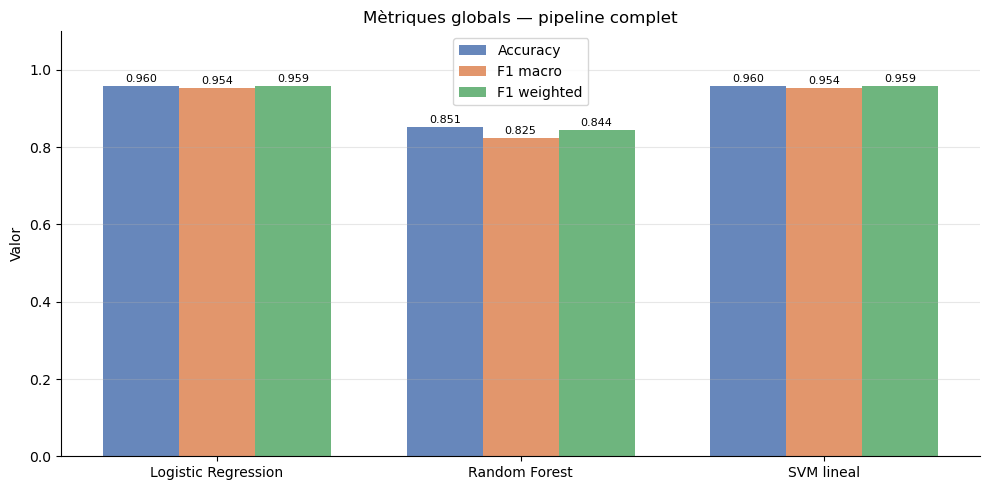

In [12]:
# ── 4.1. Visualització de mètriques globals ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(model_names))
width = 0.25
metric_cols = ['Accuracy', 'F1 macro', 'F1 weighted']
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, (col, color) in enumerate(zip(metric_cols, colors)):
    vals = [global_metrics_df.loc[model_display_names[name], col] for name in model_names]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=col, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([model_display_names[n] for n in model_names])
ax.set_ylabel('Valor')
ax.set_ylim(0, 1.1)
ax.set_title('Mètriques globals — pipeline complet')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'global_metrics_full_pipeline.png', dpi=150)
plt.show()

### 4.2. Interpretació dels resultats globals

La taula de mètriques globals permet comparar el rendiment general dels classificadors entrenats amb el pipeline complet. L'accuracy mostra la proporció total d'encerts, mentre que el F1 macro dona el mateix pes a totes les classes i permet valorar millor l'equilibri del rendiment entre subtipus.

La comparació entre F1 macro i F1 weighted permet detectar si el rendiment global està influït per les classes amb més mostres. Quan el F1 weighted és superior al F1 macro, pot indicar que el model funciona millor en classes més representades que en classes minoritàries.

Aquesta interpretació és descriptiva. Les diferències observades entre models es contrasten estadísticament en apartats posteriors.

In [13]:
# ── 4.3. Resultats per subtipus CMS — Taula de F1-score per classe ───────────
f1_rows = []
for name in model_names:
    pred = full_preds[name]
    report = classification_report(y_test, pred, output_dict=True)
    row = {'Model': model_display_names[name]}
    for cls in class_labels:
        row[cls] = round(report[cls]['f1-score'], 4)
    row['Mitjana classes'] = round(
        np.mean([report[cls]['f1-score'] for cls in class_labels]), 4
    )
    f1_rows.append(row)

f1_per_class_df = pd.DataFrame(f1_rows).set_index('Model')
display(f1_per_class_df)

,CMS1,CMS2,CMS3,CMS4,Mitjana classes
Model,,,,,
Logistic Regression,0.9333,0.9831,0.9524,0.9474,0.9540
Random Forest,0.8667,0.8923,0.7059,0.8333,0.8245
SVM lineal,0.9333,0.9831,0.9524,0.9474,0.9540


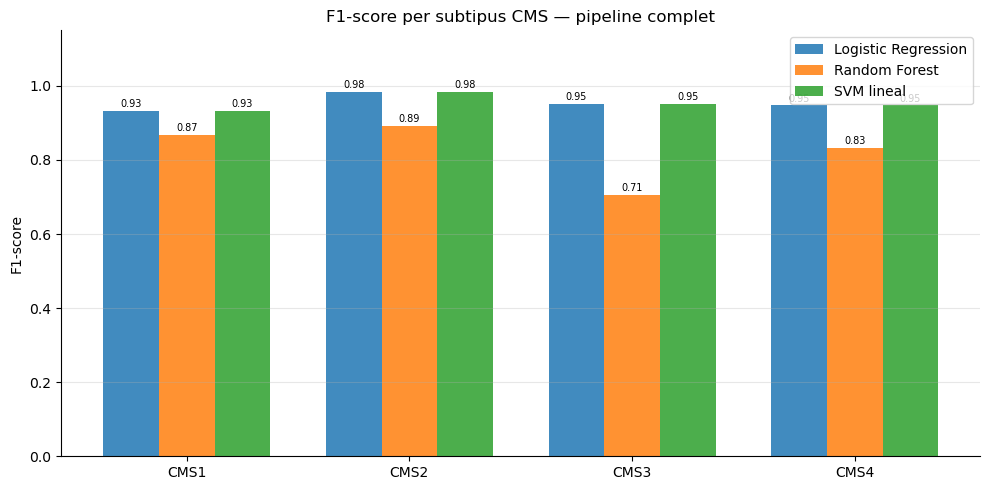

In [14]:
# ── 4.4. Visualització del F1-score per classe ───────────────────────────────
model_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
x = np.arange(len(class_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, name in enumerate(model_names):
    vals = [f1_per_class_df.loc[model_display_names[name], cls] for cls in class_labels]
    bars = ax.bar(x + (i - 1) * width, vals, width,
                  label=model_display_names[name], color=model_colors[i], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(class_labels)
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.15)
ax.set_title('F1-score per subtipus CMS — pipeline complet')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'f1_per_class_full_pipeline.png', dpi=150)
plt.show()

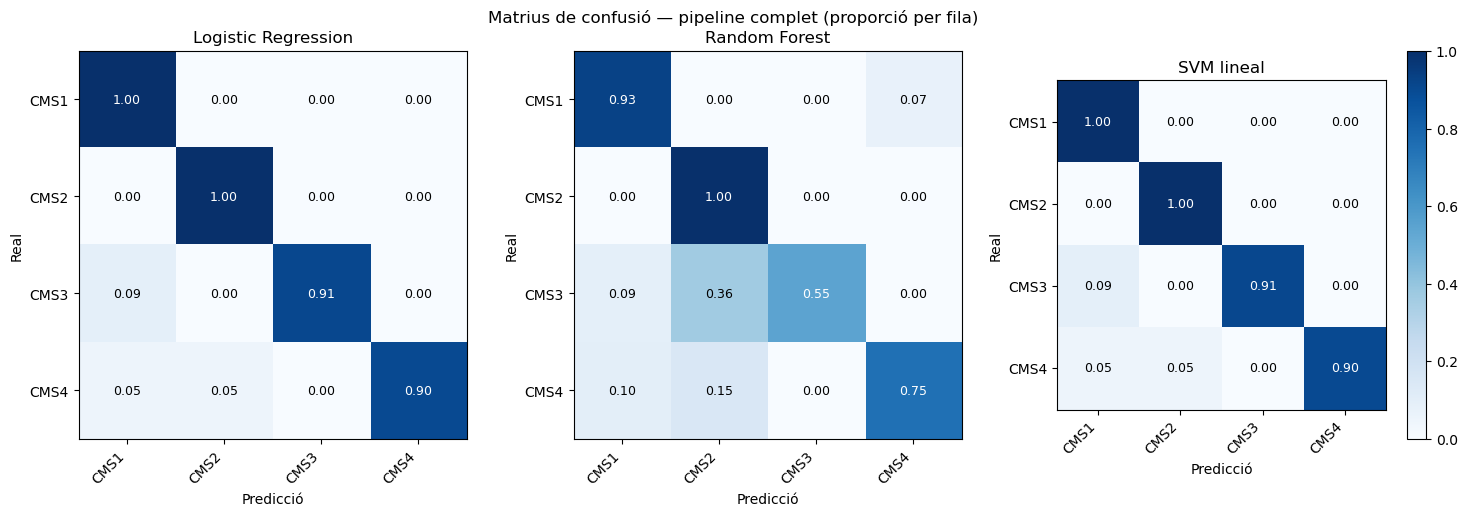

In [15]:
# ── 4.5. Matrius de confusió ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Matrius de confusió — pipeline complet (proporció per fila)', fontsize=12)

for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_test, full_preds[name], labels=class_labels, normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(class_labels)))
    ax.set_yticks(range(len(class_labels)))
    ax.set_xticklabels(class_labels, rotation=45, ha='right')
    ax.set_yticklabels(class_labels)
    for i in range(len(class_labels)):
        for j in range(len(class_labels)):
            ax.text(j, i, f'{cm[i, j]:.2f}', ha='center', va='center',
                    fontsize=9, color='white' if cm[i, j] > 0.5 else 'black')
    ax.set_xlabel('Predicció')
    ax.set_ylabel('Real')
    ax.set_title(model_display_names[name])

plt.colorbar(im, ax=axes[-1])
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrices_full_pipeline.png', dpi=150)
plt.show()

In [16]:
# ── 4.6. Errors més freqüents ────────────────────────────────────────────────
error_rows = []
for name in model_names:
    _yt = np.array(y_test)
    _yp = np.array(full_preds[name])
    mask = _yt != _yp
    counts = Counter(zip(_yt[mask], _yp[mask]))
    for (real, predicted), count in sorted(counts.items(), key=lambda x: -x[1]):
        error_rows.append({
            'Model':            model_display_names[name],
            'Classe real':      real,
            'Classe predita':   predicted,
            "Nombre d'errors":  count,
        })

top_errors_df = pd.DataFrame(error_rows)
display(top_errors_df[top_errors_df["Nombre d'errors"] > 0].reset_index(drop=True))

,Model,Classe real,Classe predita,Nombre d'errors
0,Logistic Regression,CMS3,CMS1,1
1,Logistic Regression,CMS4,CMS1,1
2,Logistic Regression,CMS4,CMS2,1
3,Random Forest,CMS3,CMS2,4
4,Random Forest,CMS4,CMS2,3
5,Random Forest,CMS4,CMS1,2
6,Random Forest,CMS3,CMS1,1
7,Random Forest,CMS1,CMS4,1
8,SVM lineal,CMS3,CMS1,1
9,SVM lineal,CMS4,CMS1,1


L'anàlisi d'errors permet identificar quines confusions entre subtipus són més freqüents. Aquesta informació complementa les mètriques globals i el F1 per classe, ja que mostra de manera explícita cap a quines classes es desplacen les prediccions incorrectes.

Aquesta interpretació és descriptiva i no implica cap conclusió estadística. Els contrastos formals es desenvolupen en els apartats posteriors.

In [17]:
# ── 5. Comparació entre classificadors ───────────────────────────────────────
_comparisons = [
    ('logistic_regression', 'random_forest'),
    ('svm',                 'random_forest'),
    ('logistic_regression', 'svm'),
]
_y = np.array(y_test)

agreement_rows = []
for name_a, name_b in _comparisons:
    pa = np.array(full_preds[name_a])
    pb = np.array(full_preds[name_b])
    agreement_rows.append({
        'Comparació':                    f'{model_display_names[name_a]} vs {model_display_names[name_b]}',
        'Prediccions idèntiques':        int((pa == pb).sum()),
        'Discrepàncies':                 int((pa != pb).sum()),
        '% coincidència':                round((pa == pb).mean() * 100, 1),
        'A correcte / B incorrecte':     int(((pa == _y) & (pb != _y)).sum()),
        'A incorrecte / B correcte':     int(((pa != _y) & (pb == _y)).sum()),
        'Tots dos correctes':            int(((pa == _y) & (pb == _y)).sum()),
        'Tots dos incorrectes':          int(((pa != _y) & (pb != _y)).sum()),
    })

prediction_agreement_df = pd.DataFrame(agreement_rows).set_index('Comparació')
display(prediction_agreement_df)

,Prediccions idèntiques,Discrepàncies,% coincidència,A correcte / B incorrecte,A incorrecte / B correcte,Tots dos correctes,Tots dos incorrectes
Comparació,,,,,,,
Logistic Regression vs Random Forest,66,8,89.2,8,0,63,3
SVM lineal vs Random Forest,66,8,89.2,8,0,63,3
Logistic Regression vs SVM lineal,74,0,100.0,0,0,71,3


### 5.1. Interpretació de la comparació directa

La comparació directa de prediccions permet analitzar si dos classificadors tendeixen a prendre les mateixes decisions sobre les mateixes mostres. Un percentatge elevat de coincidència indica que els models generen prediccions similars, encara que el seu funcionament intern sigui diferent.

Els casos discordants són especialment rellevants, perquè indiquen mostres en què un model encerta i l'altre falla. Aquests casos s'utilitzen posteriorment en el test exacte de McNemar per valorar si la diferència entre dos classificadors disposa de suport estadístic.

En aquest apartat, la comparació és descriptiva. La interpretació estadística es desenvolupa en els apartats dedicats als contrastos d'hipòtesis.

## 6. Mètodes estadístics

Les mètriques descriptives permeten comparar el rendiment observat dels classificadors, però no indiquen per si soles si les diferències són estadísticament consistents. Per aquest motiu, l'avaluació incorpora contrastos estadístics aplicats sobre el conjunt de test.

En aquest notebook s'utilitzen dos enfocaments complementaris. El test exacte de McNemar compara dos classificadors sobre les mateixes mostres i analitza els casos en què un model encerta i l'altre falla. El bootstrap estima la variabilitat de les mètriques mitjançant re-mostreig amb reemplaçament i permet construir intervals de confiança.

Aquests mètodes s'utilitzen per contrastar les hipòtesis H1, H2, H3, H4 i H5. Les hipòtesis H1, H2 i H5 es formulen com comparacions direccionals. La hipòtesi H3 es tracta com una hipòtesi d'equivalència pràctica. La hipòtesi H4 se centra en la dificultat relativa del subtipus CMS3 respecte a la resta de subtipus.

### 6.1. Interpretació del p-value

El p-value representa la probabilitat d'obtenir un resultat tan extrem com l'observat, o més extrem, assumint que la hipòtesi nul·la és certa.

En aquest notebook, el llindar de significació utilitzat és α = 0,05.

El criteri de decisió és el següent:
- si p-value < 0,05, es rebutja H₀;
- si p-value ≥ 0,05, no es pot rebutjar H₀.

No s'utilitza la formulació "s'accepta H₀". Quan el p-value no és inferior al llindar de significació, la interpretació correcta és que no hi ha evidència suficient per rebutjar la hipòtesi nul·la amb les dades disponibles.

### 6.2. Test exacte de McNemar

El test de McNemar s'aplica quan dos classificadors s'avaluen sobre les mateixes mostres. La prova compara els patrons d'encert i error dels dos models i se centra només en les mostres discordants.

La taula de contingència és:

| | Model B correcte | Model B incorrecte |
|---|---:|---:|
| **Model A correcte** | a | b |
| **Model A incorrecte** | c | d |

Els valors rellevants són **b** i **c**. **b** és el nombre de mostres on el model A encerta i el model B falla. **c** és el nombre de mostres on el model A falla i el model B encerta.

Sota la hipòtesi nul·la, els dos models tenen la mateixa probabilitat de ser el model correcte en els casos discordants:

$$X \sim \text{Binomial}(b + c,\; 0{,}5)$$

Quan la hipòtesi alternativa és direccional, el p-value es calcula com P(X ≥ b). Aquest enfocament s'utilitza per a H1, H2 i H5. En H3, McNemar s'utilitza com a contrast complementari, però no com a prova d'equivalència pràctica.

### 6.3. Bootstrap i intervals de confiança

El bootstrap és un mètode de re-mostreig que permet estimar la variabilitat d'una mètrica sense assumir una distribució específica de les dades. En cada iteració es genera una mostra del mateix tamany que el conjunt de test, escollint observacions amb reemplaçament. La mètrica d'interès es calcula sobre cada mostra i l'interval de confiança al 95% s'obté com els percentils 2,5 i 97,5 de la distribució resultant.

En aquest notebook s'utilitzen N_BOOT = 2.000 iteracions amb una llavor fixa (RANDOM_STATE = 42) per garantir la reproducibilitat dels intervals.

El bootstrap s'aplica amb tres finalitats:
- Estimar la variabilitat de la diferència de F1 macro entre dos models (hipòtesis H1, H2 i H5).
- Avaluar si la diferència entre Logistic Regression i SVM lineal és compatible amb el marge d'equivalència ε = 0,02 (H3).
- Comparar el F1-score de CMS3 respecte a la mitjana del F1 de les altres classes (H4).

Quan l'interval de confiança del 95% no inclou el zero, la diferència observada és consistent amb les dades. Quan l'interval inclou el zero, la diferència no és concloent amb les dades disponibles.

In [30]:
# ── 6.4. Funcions estadístiques ───────────────────────────────────────────────
def mcnemar_exact(pred_a, pred_b, y_true, alternative='greater'):
    a_arr, b_arr, y_arr = np.array(pred_a), np.array(pred_b), np.array(y_true)
    correct_a = a_arr == y_arr
    correct_b = b_arr == y_arr
    b = int((correct_a & ~correct_b).sum())
    c = int((~correct_a & correct_b).sum())
    n = b + c
    if n == 0:
        return {'b': b, 'c': c, 'n_discordant': 0,
                'p_value': None, 'decisio': 'No aplicable (prediccions idèntiques)'}
    k = b if alternative == 'greater' else min(b, c)
    p_value = float(binomtest(k=k, n=n, p=0.5, alternative=alternative).pvalue)
    decisio = 'Es rebutja H₀' if p_value < ALPHA else 'No es pot rebutjar H₀'
    return {'b': b, 'c': c, 'n_discordant': n,
            'p_value': round(p_value, 6), 'decisio': f'{decisio} (α={ALPHA})'}


def bootstrap_delta_f1_macro(y_true, pred_a, pred_b, n_boot=N_BOOT, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_arr, a_arr, b_arr = np.array(y_true), np.array(pred_a), np.array(pred_b)
    n = len(y_arr)
    obs = f1_score(y_arr, a_arr, average='macro') - f1_score(y_arr, b_arr, average='macro')
    deltas = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        fa = f1_score(y_arr[idx], a_arr[idx], average='macro', zero_division=0)
        fb = f1_score(y_arr[idx], b_arr[idx], average='macro', zero_division=0)
        deltas.append(fa - fb)
    return {
        'delta_observat':       round(obs, 4),
        'delta_bootstrap_mean': round(float(np.mean(deltas)), 4),
        'ci_low':               round(float(np.percentile(deltas, 2.5)), 4),
        'ci_high':              round(float(np.percentile(deltas, 97.5)), 4),
    }


def bootstrap_f1_macro(y_true, y_pred, n_boot=N_BOOT, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_arr, p_arr = np.array(y_true), np.array(y_pred)
    n = len(y_arr)
    obs = f1_score(y_arr, p_arr, average='macro')
    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        scores.append(f1_score(y_arr[idx], p_arr[idx], average='macro', zero_division=0))
    return {
        'f1_observat':       round(obs, 4),
        'f1_bootstrap_mean': round(float(np.mean(scores)), 4),
        'ci_low':            round(float(np.percentile(scores, 2.5)), 4),
        'ci_high':           round(float(np.percentile(scores, 97.5)), 4),
    }


def bootstrap_cms3_vs_others(y_true, y_pred, labels, n_boot=N_BOOT, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_arr, p_arr = np.array(y_true), np.array(y_pred)
    n = len(y_arr)
    others = [c for c in labels if c != 'CMS3']
    obs_vals = f1_score(y_arr, p_arr, labels=labels, average=None, zero_division=0)
    obs_dict = dict(zip(labels, obs_vals))
    obs_delta = obs_dict['CMS3'] - np.mean([obs_dict[c] for c in others])
    deltas = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        vals = f1_score(y_arr[idx], p_arr[idx], labels=labels, average=None, zero_division=0)
        d = dict(zip(labels, vals))
        deltas.append(d['CMS3'] - np.mean([d[c] for c in others]))
    return {
        'f1_cms3':        round(obs_dict['CMS3'], 4),
        'f1_mean_others': round(float(np.mean([obs_dict[c] for c in others])), 4),
        'delta_observat': round(obs_delta, 4),
        'ci_low':         round(float(np.percentile(deltas, 2.5)), 4),
        'ci_high':        round(float(np.percentile(deltas, 97.5)), 4),
    }


def interpret_delta_ci(ci_low, ci_high):
    if ci_low > 0:
        return 'Diferència positiva consistent'
    if ci_high < 0:
        return 'Diferència negativa consistent'
    return 'Diferència no concloent'


def interpret_equivalence_ci(ci_low, ci_high, epsilon=EPSILON_EQUIVALENCE):
    if ci_low >= -epsilon and ci_high <= epsilon:
        return 'Equivalència pràctica compatible'
    return 'Equivalència no concloent'


print('Funcions estadístiques definides correctament.')

Funcions estadístiques definides correctament.


## 7. Contrast de les hipòtesis sobre models

En aquest apartat es contrasten les hipòtesis H1, H2, H3 i H4, que fan referència al comportament dels classificadors entrenats amb el pipeline complet.

Les hipòtesis H1 i H2 comparen el rendiment global dels models lineals respecte a Random Forest. La hipòtesi H3 analitza si Logistic Regression i SVM lineal presenten un comportament pràcticament equivalent. La hipòtesi H4 avalua si el subtipus CMS3 presenta més dificultat de classificació que la resta de subtipus.

Els resultats d'aquest apartat es basen en les prediccions del pipeline complet. L'anàlisi del pipeline minimal es desenvolupa posteriorment a l'apartat d'ablació del preprocessament.

In [31]:
# ── 7.1. H1: Logistic Regression vs Random Forest ────────────────────────────
_pred_lr = np.array(full_preds['logistic_regression'])
_pred_rf = np.array(full_preds['random_forest'])

_f1_lr = round(f1_score(y_test, _pred_lr, average='macro'), 4)
_f1_rf = round(f1_score(y_test, _pred_rf, average='macro'), 4)

_h1_mc   = mcnemar_exact(_pred_lr, _pred_rf, y_test, alternative='greater')
_h1_boot = bootstrap_delta_f1_macro(y_test, _pred_lr, _pred_rf)
_h1_interp = interpret_delta_ci(_h1_boot['ci_low'], _h1_boot['ci_high'])

h1_results = {
    'f1_lr': _f1_lr, 'f1_rf': _f1_rf,
    'delta': _h1_boot['delta_observat'],
    'mcnemar': _h1_mc, 'bootstrap': _h1_boot,
}

display(pd.DataFrame([
    ('F1 macro Logistic Regression',    _f1_lr),
    ('F1 macro Random Forest',          _f1_rf),
    ('Δ F1 macro (LR − RF)',            _h1_boot['delta_observat']),
    ('b (LR correcte / RF incorrecte)', _h1_mc['b']),
    ('c (LR incorrecte / RF correcte)', _h1_mc['c']),
    ('n discordants',                   _h1_mc['n_discordant']),
    ('p-value McNemar',                 _h1_mc['p_value']),
    ('IC 95% inferior (bootstrap Δ)',   _h1_boot['ci_low']),
    ('IC 95% superior (bootstrap Δ)',   _h1_boot['ci_high']),
    ('Interpretació bootstrap',         _h1_interp),
], columns=['Mètode', 'Valor']).set_index('Mètode'))

,Valor
Mètode,
F1 macro Logistic Regression,0.954
F1 macro Random Forest,0.8245
Δ F1 macro (LR − RF),0.1295
b (LR correcte / RF incorrecte),8
c (LR incorrecte / RF correcte),0
n discordants,8
p-value McNemar,0.003906
IC 95% inferior (bootstrap Δ),0.0517
IC 95% superior (bootstrap Δ),0.2288


#### 7.1.1. Interpretació dels resultats de H1

La taula mostra la diferència de F1 macro entre Logistic Regression i Random Forest, juntament amb els resultats del test de McNemar i del bootstrap.

El p-value del test de McNemar indica la probabilitat de la distribució de casos discordants observada (b i c) assumint que H₀ és certa. Un p-value inferior a α = 0,05 significa que el nombre de mostres on Logistic Regression encerta i Random Forest falla és estadísticament inconsistent amb la hipòtesi que tots dos models tenen el mateix comportament.

L'interval de confiança bootstrap al 95% de la diferència de F1 macro (LR − RF) quantifica la variabilitat estimada d'aquesta diferència per re-mostreig. Quan el límit inferior de l'interval és positiu, la diferència és consistent en tots els escenaris de re-mostreig analitzats.

La resolució formal de H1 es presenta a l'apartat 9.

In [32]:
# ── 7.2. H2: SVM lineal vs Random Forest ─────────────────────────────────────
_pred_svm2 = np.array(full_preds['svm'])
_pred_rf2  = np.array(full_preds['random_forest'])

_f1_svm2 = round(f1_score(y_test, _pred_svm2, average='macro'), 4)
_f1_rf2  = round(f1_score(y_test, _pred_rf2,  average='macro'), 4)

_h2_mc   = mcnemar_exact(_pred_svm2, _pred_rf2, y_test, alternative='greater')
_h2_boot = bootstrap_delta_f1_macro(y_test, _pred_svm2, _pred_rf2)
_h2_interp = interpret_delta_ci(_h2_boot['ci_low'], _h2_boot['ci_high'])

h2_results = {
    'f1_svm': _f1_svm2, 'f1_rf': _f1_rf2,
    'delta': _h2_boot['delta_observat'],
    'mcnemar': _h2_mc, 'bootstrap': _h2_boot,
}

display(pd.DataFrame([
    ('F1 macro SVM lineal',               _f1_svm2),
    ('F1 macro Random Forest',            _f1_rf2),
    ('Δ F1 macro (SVM − RF)',             _h2_boot['delta_observat']),
    ('b (SVM correcte / RF incorrecte)',  _h2_mc['b']),
    ('c (SVM incorrecte / RF correcte)',  _h2_mc['c']),
    ('n discordants',                     _h2_mc['n_discordant']),
    ('p-value McNemar',                   _h2_mc['p_value']),
    ('IC 95% inferior (bootstrap Δ)',     _h2_boot['ci_low']),
    ('IC 95% superior (bootstrap Δ)',     _h2_boot['ci_high']),
    ('Interpretació bootstrap',           _h2_interp),
], columns=['Mètode', 'Valor']).set_index('Mètode'))

,Valor
Mètode,
F1 macro SVM lineal,0.954
F1 macro Random Forest,0.8245
Δ F1 macro (SVM − RF),0.1295
b (SVM correcte / RF incorrecte),8
c (SVM incorrecte / RF correcte),0
n discordants,8
p-value McNemar,0.003906
IC 95% inferior (bootstrap Δ),0.0517
IC 95% superior (bootstrap Δ),0.2288


#### 7.2.1. Interpretació dels resultats de H2

La taula mostra la diferència de F1 macro entre SVM lineal i Random Forest, juntament amb els resultats del test de McNemar i del bootstrap.

L'estructura del contrast és equivalent a la de H1: el test de McNemar analitza els casos discordants entre SVM lineal i Random Forest, i el bootstrap estima la variabilitat de la diferència de F1 macro. Quan el p-value és inferior a α = 0,05 i el límit inferior de l'interval de confiança és positiu, l'evidència és concurrent en favor de H₁: SVM lineal supera Random Forest en F1 macro.

La resolució formal de H2 es presenta a l'apartat 9.

In [33]:
# ── 7.3. H3: equivalència pràctica LR ≡ SVM lineal ───────────────────────────
_pred_lr3  = np.array(full_preds['logistic_regression'])
_pred_svm3 = np.array(full_preds['svm'])
_y3 = np.array(y_test)

_f1_lr3  = round(f1_score(_y3, _pred_lr3, average='macro'), 4)
_f1_svm3 = round(f1_score(_y3, _pred_svm3, average='macro'), 4)
_identical    = int((_pred_lr3 == _pred_svm3).sum())
_pct_identical = round(_identical / len(_y3) * 100, 1)
_discrepances = int((_pred_lr3 != _pred_svm3).sum())

_h3_mc   = mcnemar_exact(_pred_lr3, _pred_svm3, _y3, alternative='two-sided')
_h3_boot = bootstrap_delta_f1_macro(_y3, _pred_lr3, _pred_svm3)
_h3_equiv = interpret_equivalence_ci(_h3_boot['ci_low'], _h3_boot['ci_high'])

h3_results = {
    'f1_lr': _f1_lr3, 'f1_svm': _f1_svm3,
    'delta': _h3_boot['delta_observat'],
    'abs_delta': round(abs(_h3_boot['delta_observat']), 4),
    'identical': _identical, 'pct_identical': _pct_identical,
    'mcnemar': _h3_mc, 'bootstrap': _h3_boot, 'equiv': _h3_equiv,
}

display(pd.DataFrame([
    ('F1 macro Logistic Regression',    _f1_lr3),
    ('F1 macro SVM lineal',             _f1_svm3),
    ('Δ F1 macro (LR − SVM)',           _h3_boot['delta_observat']),
    ('|Δ| F1 macro',                    h3_results['abs_delta']),
    ('Marge ε',                         EPSILON_EQUIVALENCE),
    ('Prediccions idèntiques',          _identical),
    ('Percentatge de coincidència (%)', _pct_identical),
    ('Discrepàncies',                   _discrepances),
    ('p-value McNemar (bilateral)',     _h3_mc['p_value']),
    ('IC 95% inferior (bootstrap Δ)',   _h3_boot['ci_low']),
    ('IC 95% superior (bootstrap Δ)',   _h3_boot['ci_high']),
    ('Interpretació equivalència',      _h3_equiv),
], columns=['Mètode', 'Valor']).set_index('Mètode'))

,Valor
Mètode,
F1 macro Logistic Regression,0.954
F1 macro SVM lineal,0.954
Δ F1 macro (LR − SVM),0.0
|Δ| F1 macro,0.0
Marge ε,0.02
Prediccions idèntiques,74
Percentatge de coincidència (%),100.0
Discrepàncies,0
p-value McNemar (bilateral),None


#### 7.3.1. Interpretació dels resultats de H3

H3 no és una hipòtesi de superioritat sinó d'equivalència pràctica. S'avalua si la diferència absoluta entre el F1 macro de la Logistic Regression i el de la SVM lineal és inferior al marge ε = 0,02.

L'interval de confiança bootstrap al 95% de la diferència de F1 macro (LR − SVM) és l'evidència principal. Si l'interval és enterament dins de [−ε, +ε], les dades observades són compatibles amb l'equivalència pràctica. Si l'interval supera un o tots dos extrems del marge, l'equivalència no queda confirmada.

El percentatge de prediccions idèntiques complementa la interpretació: si tots dos models generen les mateixes prediccions sobre el conjunt de test, la diferència de F1 macro és necessàriament zero i el test de McNemar bilateral no és aplicable.

La resolució formal de H3 es presenta a l'apartat 9.

In [34]:
# ── 7.4. H4: dificultat específica de CMS3 ───────────────────────────────────
h4_rows = []
for name in model_names:
    res = bootstrap_cms3_vs_others(y_test, full_preds[name], class_labels)
    h4_rows.append({
        'Model':           model_display_names[name],
        'F1 CMS3':         res['f1_cms3'],
        'F1 mitjà resta':  res['f1_mean_others'],
        'Δ CMS3':          res['delta_observat'],
        'IC 95% inferior': res['ci_low'],
        'IC 95% superior': res['ci_high'],
        'Interpretació':   interpret_delta_ci(res['ci_low'], res['ci_high']),
    })

h4_results_df = pd.DataFrame(h4_rows).set_index('Model')
display(h4_results_df)

,F1 CMS3,F1 mitjà resta,Δ CMS3,IC 95% inferior,IC 95% superior,Interpretació
Model,,,,,,
Logistic Regression,0.9524,0.9546,-0.0022,-0.1179,0.0768,Diferència no concloent
Random Forest,0.7059,0.8641,-0.1582,-0.4656,0.0450,Diferència no concloent
SVM lineal,0.9524,0.9546,-0.0022,-0.1179,0.0768,Diferència no concloent


#### 7.4.1. Interpretació dels resultats de H4

La taula mostra, per a cada model, la diferència entre el F1-score de CMS3 i la mitjana del F1-score de les altres classes (CMS1, CMS2, CMS4), estimada amb bootstrap.

Quan l'interval de confiança al 95% del Δ CMS3 és enterament negatiu, la dificultat de CMS3 respecte a la resta de classes és consistent amb les dades observades. Quan l'interval inclou el zero, la diferència no és concloent.

El resultat pot variar entre models. Si un o més classificadors presenten un interval enterament negatiu però algun altre no, la hipòtesi queda confirmada parcialment, i la dificultat específica de CMS3 dependria del tipus de model.

La resolució formal de H4 es presenta a l'apartat 9.

In [35]:
# ── 7.5. Resum provisional del contrast H1-H4 ────────────────────────────────
_summary_rows = [
    {
        'Hipòtesi': 'H1', 'Comparació': 'LR vs RF',
        'Evidència descriptiva': f'Δ F1 macro = {h1_results["delta"]:+.4f}',
        'Evidència estadística': (
            f'McNemar p={h1_results["mcnemar"]["p_value"]} | '
            f'IC [{h1_results["bootstrap"]["ci_low"]:.4f}, {h1_results["bootstrap"]["ci_high"]:.4f}]'
        ),
        'Estat provisional': interpret_delta_ci(
            h1_results['bootstrap']['ci_low'], h1_results['bootstrap']['ci_high']
        ),
    },
    {
        'Hipòtesi': 'H2', 'Comparació': 'SVM vs RF',
        'Evidència descriptiva': f'Δ F1 macro = {h2_results["delta"]:+.4f}',
        'Evidència estadística': (
            f'McNemar p={h2_results["mcnemar"]["p_value"]} | '
            f'IC [{h2_results["bootstrap"]["ci_low"]:.4f}, {h2_results["bootstrap"]["ci_high"]:.4f}]'
        ),
        'Estat provisional': interpret_delta_ci(
            h2_results['bootstrap']['ci_low'], h2_results['bootstrap']['ci_high']
        ),
    },
    {
        'Hipòtesi': 'H3', 'Comparació': 'LR ≡ SVM',
        'Evidència descriptiva': (
            f'|Δ| = {h3_results["abs_delta"]:.4f} | '
            f'Coincidència {h3_results["pct_identical"]:.1f}%'
        ),
        'Evidència estadística': (
            f'IC [{h3_results["bootstrap"]["ci_low"]:.4f}, {h3_results["bootstrap"]["ci_high"]:.4f}]'
            f' | ε = {EPSILON_EQUIVALENCE}'
        ),
        'Estat provisional': h3_results['equiv'],
    },
    {
        'Hipòtesi': 'H4', 'Comparació': 'CMS3 vs resta',
        'Evidència descriptiva': ' | '.join(
            f'{model_display_names[n]}: Δ={h4_results_df.loc[model_display_names[n], "Δ CMS3"]:+.4f}'
            for n in model_names
        ),
        'Evidència estadística': ' | '.join(
            f'IC [{h4_results_df.loc[model_display_names[n], "IC 95% inferior"]:.4f}, '
            f'{h4_results_df.loc[model_display_names[n], "IC 95% superior"]:.4f}]'
            for n in model_names
        ),
        'Estat provisional': (
            'Diferència negativa consistent (RF)'
            if any(h4_results_df.loc[model_display_names[n], 'IC 95% superior'] < 0
                   for n in model_names)
            else 'Diferència no concloent'
        ),
    },
]
model_hypotheses_summary_df = pd.DataFrame(_summary_rows).set_index('Hipòtesi')
display(model_hypotheses_summary_df)

,Comparació,Evidència descriptiva,Evidència estadística,Estat provisional
Hipòtesi,,,,
H1,LR vs RF,Δ F1 macro = +0.1295,"McNemar p=0.003906 | IC [0.0517, 0.2288]",Diferència positiva consistent
H2,SVM vs RF,Δ F1 macro = +0.1295,"McNemar p=0.003906 | IC [0.0517, 0.2288]",Diferència positiva consistent
H3,LR ≡ SVM,|Δ| = 0.0000 | Coincidència 100.0%,"IC [0.0000, 0.0000] | ε = 0.02",Equivalència pràctica compatible
H4,CMS3 vs resta,Logistic Regression: Δ=-0.0022 | Random Forest...,"IC [-0.1179, 0.0768] | IC [-0.4656, 0.0450] | ...",Diferència no concloent


## 8. Anàlisi d'ablació del preprocessament

Aquest apartat avalua la hipòtesi H5, centrada en l'impacte del preprocessament sobre el rendiment dels classificadors. L'anàlisi compara el pipeline complet amb una versió de preprocessament mínim.

L'objectiu no és comparar dades processades amb dades completament crues, sinó aïllar l'efecte de dues transformacions concretes: el filtratge de gens amb baixa expressió i la transformació log₂(x+1).

Aquesta anàlisi és complementària a l'avaluació principal. El pipeline complet continua sent la condició principal del projecte, mentre que el pipeline minimal s'utilitza com a condició experimental per valorar l'impacte d'aquestes decisions de preprocessament.

### 8.1. Definició de les condicions comparades

La comparació d'ablació es defineix a partir de dues condicions experimentals:

| Condició | Descripció | Ús |
|---|---|---|
| Pipeline complet | Dataset amb filtratge de gens amb baixa expressió i transformació log₂(x+1) | Avaluació principal dels classificadors |
| Pipeline minimal | Dataset amb preprocessament mínim, sense filtratge de gens amb baixa expressió i sense transformació log₂(x+1) | Anàlisi d'ablació del preprocessament |

El pipeline minimal conserva els passos necessaris per obtenir una matriu coherent i comparable: mostres vàlides, etiquetes CMS, mateix split train/test i estructura compatible entre train i test.

Per tant, el terme "minimal" no indica absència total de preprocessament. Indica que s'han retirat dues transformacions finals per estimar-ne l'impacte sobre els resultats.

In [36]:
# ── 8.2. Comparació descriptiva full vs minimal ───────────────────────────────
if minimal_available:
    ablation_rows = []
    for name in model_names:
        pred_full = full_preds[name]
        pred_min  = minimal_preds[name]
        f1_full = round(f1_score(y_test, pred_full, average='macro'), 4)
        f1_min  = round(minimal_report[name]['f1_macro'], 4)
        ablation_rows.append({
            'Model':               model_display_names[name],
            'Accuracy full':       round(accuracy_score(y_test, pred_full), 4),
            'Accuracy minimal':    round(accuracy_score(y_test, pred_min), 4),
            'F1 macro full':       f1_full,
            'F1 macro minimal':    f1_min,
            'Δ F1 macro':          round(f1_full - f1_min, 4),
            'F1 weighted full':    round(f1_score(y_test, pred_full, average='weighted'), 4),
            'F1 weighted minimal': round(f1_score(y_test, pred_min, average='weighted'), 4),
        })
    ablation_metrics_df = pd.DataFrame(ablation_rows).set_index('Model')
    display(ablation_metrics_df)
else:
    ablation_metrics_df = pd.DataFrame()
    print("No es pot generar la comparació full vs minimal perquè els fitxers "
          "del pipeline minimal no estan disponibles.")

,Accuracy full,Accuracy minimal,F1 macro full,F1 macro minimal,Δ F1 macro,F1 weighted full,F1 weighted minimal
Model,,,,,,,
Logistic Regression,0.9595,0.7703,0.9540,0.7691,0.1849,0.9594,0.7794
Random Forest,0.8514,0.8378,0.8245,0.8220,0.0025,0.8438,0.8306
SVM lineal,0.9595,0.8108,0.9540,0.8026,0.1514,0.9594,0.8137


#### 8.2.1. Interpretació de la comparació descriptiva

La taula anterior, quan el pipeline minimal és disponible, mostra les mètriques principals de les dues condicions experimentals i la diferència de F1 macro (Δ F1 macro = F1 macro full − F1 macro minimal).

Un valor positiu de Δ F1 macro indica que el pipeline complet obté un rendiment superior al pipeline minimal. Un valor negatiu indicaria que les transformacions adicionals no aporten millora sobre el conjunt de test analitzat.

Aquesta comparació és descriptiva. El suport estadístic de la hipòtesi H5 es desenvolupa als apartats 8.3 i 8.4, on s'apliquen el test de McNemar i el bootstrap per avaluar si la diferència observada és estadísticament consistent.

In [37]:
# ── 8.3. McNemar per a H5: pipeline complet vs minimal ───────────────────────
if minimal_available:
    h5_mcnemar_rows = []
    for name in model_names:
        mc = mcnemar_exact(
            full_preds[name], minimal_preds[name], y_test, alternative='greater'
        )
        h5_mcnemar_rows.append({
            'Model':                       model_display_names[name],
            'b (full bé / min malament)':  mc['b'],
            'c (full malament / min bé)':  mc['c'],
            'n discordants':               mc['n_discordant'],
            'p-value McNemar':             mc['p_value'],
            'Decisió':                     mc['decisio'],
        })
    h5_mcnemar_df = pd.DataFrame(h5_mcnemar_rows).set_index('Model')
    display(h5_mcnemar_df)
else:
    h5_mcnemar_df = pd.DataFrame()
    print("H5 (McNemar): no avaluable. "
          "Els fitxers del pipeline minimal no estan disponibles.")

,b (full bé / min malament),c (full malament / min bé),n discordants,p-value McNemar,Decisió
Model,,,,,
Logistic Regression,15,1,16,0.000259,Es rebutja H₀ (α=0.05)
Random Forest,2,1,3,0.500000,No es pot rebutjar H₀ (α=0.05)
SVM lineal,13,2,15,0.003693,Es rebutja H₀ (α=0.05)


In [38]:
# ── 8.4. Bootstrap per a H5: Δ F1 macro full vs minimal ──────────────────────
if minimal_available:
    h5_boot_rows = []
    for name in model_names:
        res = bootstrap_delta_f1_macro(y_test, full_preds[name], minimal_preds[name])
        h5_boot_rows.append({
            'Model':                  model_display_names[name],
            'Δ F1 macro observat':    res['delta_observat'],
            'Δ F1 macro (bootstrap)': res['delta_bootstrap_mean'],
            'IC 95% inferior':        res['ci_low'],
            'IC 95% superior':        res['ci_high'],
            'Interpretació':          interpret_delta_ci(res['ci_low'], res['ci_high']),
        })
    h5_bootstrap_df = pd.DataFrame(h5_boot_rows).set_index('Model')
    display(h5_bootstrap_df)
else:
    h5_bootstrap_df = pd.DataFrame()
    print("H5 (bootstrap): no avaluable. "
          "Els fitxers del pipeline minimal no estan disponibles.")

,Δ F1 macro observat,Δ F1 macro (bootstrap),IC 95% inferior,IC 95% superior,Interpretació
Model,,,,,
Logistic Regression,0.1849,0.1877,0.0846,0.2957,Diferència positiva consistent
Random Forest,0.0026,0.0012,-0.0609,0.0508,Diferència no concloent
SVM lineal,0.1514,0.1551,0.0523,0.2631,Diferència positiva consistent


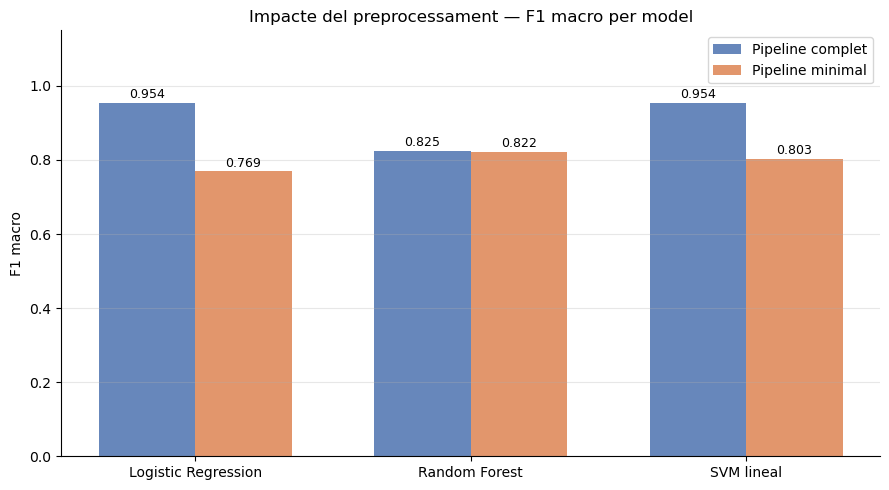

In [39]:
# ── 8.5. Visualització de l'impacte del preprocessament ──────────────────────
if minimal_available:
    _models_disp  = [model_display_names[n] for n in model_names]
    _f1_full_vals = [
        round(f1_score(y_test, full_preds[n], average='macro'), 4)
        for n in model_names
    ]
    _f1_min_vals = [
        round(minimal_report[n]['f1_macro'], 4)
        for n in model_names
    ]

    x = np.arange(len(model_names))
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 5))
    bars_full = ax.bar(x - width / 2, _f1_full_vals, width,
                       label='Pipeline complet', color='#4C72B0', alpha=0.85)
    bars_min  = ax.bar(x + width / 2, _f1_min_vals,  width,
                       label='Pipeline minimal', color='#DD8452', alpha=0.85)
    for bar, val in zip(bars_full, _f1_full_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    for bar, val in zip(bars_min, _f1_min_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(_models_disp)
    ax.set_ylabel('F1 macro')
    ax.set_ylim(0, 1.15)
    ax.set_title('Impacte del preprocessament — F1 macro per model')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'preprocessing_ablation_f1_macro.png', dpi=150)
    plt.show()
else:
    print("Visualització no disponible. "
          "Els fitxers del pipeline minimal no estan disponibles.")

#### 8.5.1. Interpretació de la visualització

Quan el pipeline minimal és disponible, el gràfic compara el F1 macro de cada model en les dues condicions experimentals. Les barres del pipeline complet i del pipeline minimal es mostren juntes per a cada classificador, de manera que la diferència visual indica la magnitud de la millora atribuïble al filtratge de gens amb baixa expressió i a la transformació log₂(x+1).

Si el pipeline complet supera el pipeline minimal en tots els models, les transformacions adicionals aportarien una millora sistemàtica del rendiment. Si les diferències varien entre models, l'impacte del preprocessament dependria del classificador.

La resolució estadística de H5 es presenta a l'apartat 9.

## 9. Resolució final de les hipòtesis

En aquest apartat es presenta la taula de resolució de les cinc hipòtesis d'avaluació. Cada hipòtesi es resol a partir dels resultats descriptius i estadístics calculats en els apartats anteriors.

In [40]:
# ── 9. Taula de resolució final de les hipòtesis ─────────────────────────────

# H1
_h1_mc_p        = h1_results['mcnemar']['p_value']
_h1_boot        = h1_results['bootstrap']
_h1_boot_interp = interpret_delta_ci(_h1_boot['ci_low'], _h1_boot['ci_high'])
_h1_verdict = (
    'Es rebutja H₀'
    if (_h1_mc_p is not None and _h1_mc_p < ALPHA
        and _h1_boot_interp == 'Diferència positiva consistent')
    else 'No es pot rebutjar H₀'
)

# H2
_h2_mc_p        = h2_results['mcnemar']['p_value']
_h2_boot        = h2_results['bootstrap']
_h2_boot_interp = interpret_delta_ci(_h2_boot['ci_low'], _h2_boot['ci_high'])
_h2_verdict = (
    'Es rebutja H₀'
    if (_h2_mc_p is not None and _h2_mc_p < ALPHA
        and _h2_boot_interp == 'Diferència positiva consistent')
    else 'No es pot rebutjar H₀'
)

# H3
_h3_verdict = h3_results['equiv']

# H4
_h4_neg = [
    h4_results_df.loc[model_display_names[n], 'IC 95% superior'] < 0
    for n in model_names
]
if all(_h4_neg):
    _h4_verdict = 'Es rebutja H₀ (tots els models)'
elif any(_h4_neg):
    _h4_verdict = 'Es rebutja H₀ (parcialment)'
else:
    _h4_verdict = 'No es pot rebutjar H₀'

# H5
if not minimal_available or h5_mcnemar_df.empty or h5_bootstrap_df.empty:
    _h5_verdict = 'No avaluable'
else:
    _h5_pos = [
        (h5_mcnemar_df.loc[model_display_names[n], 'p-value McNemar'] is not None
         and h5_mcnemar_df.loc[model_display_names[n], 'p-value McNemar'] < ALPHA
         and h5_bootstrap_df.loc[model_display_names[n], 'Interpretació']
             == 'Diferència positiva consistent')
        for n in model_names
    ]
    if all(_h5_pos):
        _h5_verdict = 'Es rebutja H₀ (tots els models)'
    elif any(_h5_pos):
        _h5_verdict = 'Es rebutja H₀ (parcialment)'
    else:
        _h5_verdict = 'No es pot rebutjar H₀'

hypotheses_resolution_df = pd.DataFrame([
    {
        'Hipòtesi':        'H1',
        'Enunciat':        'LR supera RF en F1 macro',
        'p-value McNemar': _h1_mc_p if _h1_mc_p is not None else '—',
        'IC 95%':          f'[{_h1_boot["ci_low"]:.4f}, {_h1_boot["ci_high"]:.4f}]',
        'Resolució':       _h1_verdict,
    },
    {
        'Hipòtesi':        'H2',
        'Enunciat':        'SVM lineal supera RF en F1 macro',
        'p-value McNemar': _h2_mc_p if _h2_mc_p is not None else '—',
        'IC 95%':          f'[{_h2_boot["ci_low"]:.4f}, {_h2_boot["ci_high"]:.4f}]',
        'Resolució':       _h2_verdict,
    },
    {
        'Hipòtesi':        'H3',
        'Enunciat':        'LR ≡ SVM lineal (equivalència pràctica)',
        'p-value McNemar': (
            h3_results['mcnemar']['p_value']
            if h3_results['mcnemar']['p_value'] is not None else '—'
        ),
        'IC 95%':          (
            f'[{h3_results["bootstrap"]["ci_low"]:.4f}, '
            f'{h3_results["bootstrap"]["ci_high"]:.4f}]'
        ),
        'Resolució':       _h3_verdict,
    },
    {
        'Hipòtesi':        'H4',
        'Enunciat':        'CMS3 presenta més dificultat que la resta',
        'p-value McNemar': '—',
        'IC 95%':          '(per model, apartat 7.4)',
        'Resolució':       _h4_verdict,
    },
    {
        'Hipòtesi':        'H5',
        'Enunciat':        'Preprocessament complet millora el minimal',
        'p-value McNemar': '—' if not minimal_available else '(per model, apartat 8.3)',
        'IC 95%':          '—' if not minimal_available else '(per model, apartat 8.4)',
        'Resolució':       _h5_verdict,
    },
]).set_index('Hipòtesi')
display(hypotheses_resolution_df)

,Enunciat,p-value McNemar,IC 95%,Resolució
Hipòtesi,,,,
H1,LR supera RF en F1 macro,0.003906,"[0.0517, 0.2288]",Es rebutja H₀
H2,SVM lineal supera RF en F1 macro,0.003906,"[0.0517, 0.2288]",Es rebutja H₀
H3,LR ≡ SVM lineal (equivalència pràctica),—,"[0.0000, 0.0000]",Equivalència pràctica compatible
H4,CMS3 presenta més dificultat que la resta,—,"(per model, apartat 7.4)",No es pot rebutjar H₀
H5,Preprocessament complet millora el minimal,"(per model, apartat 8.3)","(per model, apartat 8.4)",Es rebutja H₀ (parcialment)


### 9.1. Interpretació de la resolució final

La taula de resolució condensa les decisions estadístiques de les cinc hipòtesis. Per a H1 i H2, el criteri de resolució requereix que el p-value del test de McNemar sigui inferior a α = 0,05 i que el límit inferior de l'interval de confiança bootstrap sigui positiu. Quan les dues condicions es compleixen simultàniament, H₀ es rebutja.

Per a H3, el criteri és diferent. No s'avalua el rebuig de H₀ sinó la compatibilitat de l'interval de confiança amb el marge d'equivalència pràctica ε = 0,02. La resolució "Equivalència pràctica compatible" indica que l'interval és enterament dins de [−ε, +ε]. Si l'interval supera un o tots dos extrems, la resolució és "Equivalència no concloent".

Per a H4, la resolució es determina per cada model de manera independent. Si tots els intervals de confiança bootstrap del Δ CMS3 són enterament negatius, H₀ es rebutja per a tots els models. Si només alguns ho són, la resolució és parcial.

Per a H5, la resolució depèn de la disponibilitat dels fitxers del pipeline minimal. Si no estan disponibles, la hipòtesi queda com a no avaluable.

### 9.2. Síntesi de les hipòtesis

Les cinc hipòtesis d'avaluació cobreixen aspectes complementaris del benchmark: rendiment comparatiu entre models (H1, H2), equivalència entre els dos models lineals (H3), dificultat específica d'un subtipus (H4) i impacte del preprocessament (H5).

La resolució de H1 i H2 determina si la superioritat observada dels models lineals sobre Random Forest és estadísticament consistent. Si les dues hipòtesis es confirmen, queda documentada l'adequació dels models lineals amb regularització per a la classificació CMS en el règim d'alta dimensionalitat d'aquest conjunt de dades.

La resolució de H3 complementa H1 i H2. Si Logistic Regression i SVM lineal presenten un comportament pràcticament equivalent, la selecció del model lineal òptim no es pot basar únicament en el F1 macro del conjunt de test, i cal recórrer a altres criteris com la interpretabilitat dels coeficients.

La resolució de H4 aporta informació sobre la dificultat intrínseca del subtipus CMS3. Si la dificultat és consistent en tots els models, la causa probable és la naturalesa biològica del subtipus, no les característiques del classificador.

La resolució de H5 tanca l'anàlisi d'ablació. Si el pipeline complet supera el minimal de manera estadísticament consistent, les transformacions analitzades —filtratge de gens amb baixa expressió i transformació log₂(x+1)— aporten valor discriminatiu mesurable.

In [41]:
# ── 10. Resum integrat de resultats per a la discussió ───────────────────────
_tables_to_display = {
    'Taula 1. Mètriques globals (pipeline complet)':        'global_metrics_df',
    'Taula 2. F1-score per subtipus CMS':                   'f1_per_class_df',
    'Taula 3. Coincidències i discrepàncies entre models':  'prediction_agreement_df',
    'Taula 4. Resum estadístic provisional H1–H4':          'model_hypotheses_summary_df',
    'Taula 6. Resolució final de les hipòtesis':            'hypotheses_resolution_df',
}
for title, varname in _tables_to_display.items():
    if varname in globals():
        _df = globals()[varname]
        if hasattr(_df, 'empty') and not _df.empty:
            print(title)
            display(_df)
            print()

if minimal_available and 'ablation_metrics_df' in globals():
    _df5 = globals()['ablation_metrics_df']
    if hasattr(_df5, 'empty') and not _df5.empty:
        print('Taula 5. Comparació full vs minimal (ablació)')
        display(_df5)
        print()

Taula 1. Mètriques globals (pipeline complet)


,Accuracy,F1 macro,F1 weighted
Model,,,
Logistic Regression,0.9595,0.9540,0.9594
SVM lineal,0.9595,0.9540,0.9594
Random Forest,0.8514,0.8245,0.8438



Taula 2. F1-score per subtipus CMS


,CMS1,CMS2,CMS3,CMS4,Mitjana classes
Model,,,,,
Logistic Regression,0.9333,0.9831,0.9524,0.9474,0.9540
Random Forest,0.8667,0.8923,0.7059,0.8333,0.8245
SVM lineal,0.9333,0.9831,0.9524,0.9474,0.9540



Taula 3. Coincidències i discrepàncies entre models


...

,Comparació,Evidència descriptiva,Evidència estadística,Estat provisional
Hipòtesi,,,,
H1,LR vs RF,Δ F1 macro = +0.1295,"McNemar p=0.003906 | IC [0.0517, 0.2288]",Diferència positiva consistent
H2,SVM vs RF,Δ F1 macro = +0.1295,"McNemar p=0.003906 | IC [0.0517, 0.2288]",Diferència positiva consistent
H3,LR ≡ SVM,|Δ| = 0.0000 | Coincidència 100.0%,"IC [0.0000, 0.0000] | ε = 0.02",Equivalència pràctica compatible
H4,CMS3 vs resta,Logistic Regression: Δ=-0.0022 | Random Forest...,"IC [-0.1179, 0.0768] | IC [-0.4656, 0.0450] | ...",Diferència no concloent



Taula 6. Resolució final de les hipòtesis


,Enunciat,p-value McNemar,IC 95%,Resolució
Hipòtesi,,,,
H1,LR supera RF en F1 macro,0.003906,"[0.0517, 0.2288]",Es rebutja H₀
H2,SVM lineal supera RF en F1 macro,0.003906,"[0.0517, 0.2288]",Es rebutja H₀
H3,LR ≡ SVM lineal (equivalència pràctica),—,"[0.0000, 0.0000]",Equivalència pràctica compatible
H4,CMS3 presenta més dificultat que la resta,—,"(per model, apartat 7.4)",No es pot rebutjar H₀
H5,Preprocessament complet millora el minimal,"(per model, apartat 8.3)","(per model, apartat 8.4)",Es rebutja H₀ (parcialment)



Taula 5. Comparació full vs minimal (ablació)


,Accuracy full,Accuracy minimal,F1 macro full,F1 macro minimal,Δ F1 macro,F1 weighted full,F1 weighted minimal
Model,,,,,,,
Logistic Regression,0.9595,0.7703,0.9540,0.7691,0.1849,0.9594,0.7794
Random Forest,0.8514,0.8378,0.8245,0.8220,0.0025,0.8438,0.8306
SVM lineal,0.9595,0.8108,0.9540,0.8026,0.1514,0.9594,0.8137


## 10. Discussió

La discussió integra els resultats obtinguts en les seccions anteriors. L'anàlisi combina el rendiment global dels classificadors, el comportament per subtipus CMS, els patrons d'error, els contrastos estadístics i l'anàlisi d'ablació del preprocessament.

Aquesta interpretació diferencia els resultats descriptius de l'evidència estadística. Les mètriques indiquen el comportament observat dels models sobre el conjunt de test, mentre que els contrastos permeten valorar si les diferències disposen de suport estadístic segons els criteris definits.

La discussió no modifica els resultats ni els veredictes de les hipòtesis. La seva funció és interpretar-los de manera conjunta i situar-los dins del procés metodològic del projecte.

### 10.1. Rendiment global dels classificadors

Les mètriques globals permeten comparar el comportament general dels classificadors entrenats amb el pipeline complet. L'accuracy resumeix la proporció total d'encerts, mentre que el F1 macro dona el mateix pes a cada subtipus CMS i resulta especialment rellevant en un problema multiclasse amb distribució no uniforme.

La comparació entre F1 macro i F1 weighted permet valorar si el rendiment global està condicionat per les classes amb més mostres. Quan el F1 weighted és superior al F1 macro, el resultat pot indicar que el model obté millor rendiment en classes més representades que en classes minoritàries.

Els resultats globals s'han d'interpretar conjuntament amb els contrastos de les hipòtesis H1, H2 i H3. Una diferència descriptiva entre models només es considera consistent quan els contrastos estadístics donen suport a aquesta diferència. En cas contrari, la comparació s'ha de formular com una tendència observada però no concloent.

### 10.2. Rendiment per subtipus CMS i patrons d'error

L'anàlisi per subtipus CMS permet valorar si el rendiment dels models és homogeni entre classes o si alguns subtipus presenten més dificultat de classificació. Aquesta informació és necessària perquè les mètriques globals poden ocultar diferències rellevants entre classes.

Les matrius de confusió complementen el F1 per classe, ja que permeten identificar entre quins subtipus es produeixen les confusions. Dos models poden tenir valors globals similars però presentar patrons d'error diferents.

La hipòtesi H4 avalua específicament si CMS3 presenta més dificultat de classificació que la resta de subtipus. La interpretació d'aquesta hipòtesi s'ha de basar en la diferència entre el F1 de CMS3 i la mitjana del F1 de CMS1, CMS2 i CMS4, juntament amb l'interval de confiança obtingut mitjançant bootstrap.

Si CMS3 presenta un F1 inferior però l'interval de confiança inclou zero, la conclusió s'ha de formular com una evidència descriptiva no concloent. Si l'interval queda completament per sota de zero, l'evidència dona suport a la dificultat específica de CMS3.

### 10.3. Impacte del preprocessament

L'anàlisi d'ablació permet valorar l'impacte del filtratge de gens amb baixa expressió i de la transformació log₂(x+1) sobre el rendiment dels classificadors. Aquesta comparació es fa entre el pipeline complet i una versió de preprocessament mínim, mantenint constants les mostres, les etiquetes, la partició train/test i els hiperparàmetres.

El pipeline minimal no representa dades completament crues. Representa una condició experimental que elimina dues transformacions finals del preprocessament per estimar-ne l'efecte sobre els resultats.

La interpretació de H5 ha de combinar tres elements: la diferència descriptiva de F1 macro entre pipeline complet i pipeline minimal, el test exacte de McNemar i l'interval bootstrap de la diferència de F1 macro.

Si el pipeline complet millora el F1 macro però els contrastos no són concloents, la millora s'ha de descriure com una tendència descriptiva. Si el p-value és inferior a 0,05 i l'interval bootstrap queda completament per sobre de zero, l'evidència dona suport a un efecte positiu del preprocessament complet.

## 11. Limitacions

L'avaluació presenta diverses limitacions que condicionen la interpretació dels resultats. En primer lloc, el conjunt de test té una mida limitada. Aquest fet pot afectar especialment les mètriques per classe i els intervals de confiança, ja que alguns subtipus CMS poden tenir menys mostres disponibles.

En segon lloc, els resultats corresponen a una partició concreta de les dades. Tot i que la partició és estratificada i el pipeline és reproduïble, una validació amb cohorts externes permetria obtenir una estimació més robusta de la capacitat de generalització dels classificadors.

En tercer lloc, els contrastos estadístics també estan condicionats pel nombre de mostres discordants. En el cas de McNemar, si hi ha pocs casos en què un model encerta i l'altre falla, el test pot tenir poca capacitat per detectar diferències.

Finalment, l'anàlisi d'ablació del preprocessament no avalua l'efecte de tot el pipeline bioinformàtic. Només avalua l'impacte de retirar el filtratge de gens amb baixa expressió i la transformació log₂(x+1). Per tant, les conclusions sobre H5 s'han d'interpretar dins d'aquest abast concret.

### 11.1. Abast de la interpretació

Els resultats permeten comparar els classificadors dins de les condicions experimentals definides en aquest projecte. Per tant, les conclusions són vàlides per al conjunt de dades utilitzat, el split train/test definit i els hiperparàmetres seleccionats.

No es pot afirmar que un model sigui universalment superior en qualsevol conjunt de dades de càncer colorectal. La comparació s'ha d'entendre dins del marc experimental del TFG.

Tampoc es pot interpretar l'anàlisi d'ablació com una comparació entre dades processades i dades crues. El pipeline minimal conserva passos necessaris per garantir una matriu coherent i comparable. La seva funció és aïllar l'impacte de dues transformacions concretes del preprocessament.

Aquestes limitacions no invaliden l'avaluació, però en delimiten l'abast i permeten formular conclusions prudents i verificables.

## 12. Conclusions de l'avaluació

Aquest notebook ha avaluat el rendiment dels classificadors entrenats per a la classificació dels subtipus CMS del càncer colorectal. L'avaluació ha combinat mètriques globals, mètriques per classe, matrius de confusió, comparació directa de prediccions, contrastos estadístics i una anàlisi d'ablació del preprocessament.

Els resultats obtinguts permeten valorar el comportament comparatiu dels models dins del marc experimental definit. Les hipòtesis H1, H2 i H3 han permès comparar els classificadors principals. La hipòtesi H4 ha analitzat si la dificultat de classificació es concentra en el subtipus CMS3. La hipòtesi H5 ha incorporat una perspectiva metodològica sobre l'impacte del filtratge de baixa expressió i de la transformació log₂(x+1).

La resolució final de les hipòtesis proporciona una síntesi de l'evidència descriptiva i estadística. Quan les diferències observades disposen de suport estadístic, es poden formular conclusions més sòlides. Quan els contrastos no són concloents, els resultats s'han d'interpretar com a tendències descriptives.

Aquest notebook proporciona la base empírica per al capítol d'anàlisi de resultats de la memòria final del TFG i permet justificar la comparació entre models, la interpretació dels errors i el paper del preprocessament en el rendiment del pipeline.